In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np

# =========================
# COSYVOICE
# =========================

COZY_ROOT = "/content/drive/MyDrive/IASNLP Project/data/CosyVoice"

cozy_embeddings = []
cozy_labels = []

for emotion in sorted(os.listdir(COZY_ROOT)):

    emotion_path = os.path.join(
        COZY_ROOT,
        emotion,
        "wavlm_large_mean_embeddings"
    )

    if not os.path.isdir(emotion_path):
        continue

    print("Loading:", emotion)

    for file in sorted(os.listdir(emotion_path)):

        if file.endswith(".npy"):

            emb = np.load(
                os.path.join(emotion_path, file)
            )

            cozy_embeddings.append(emb)
            cozy_labels.append(emotion)

cozy_embeddings = np.array(cozy_embeddings)
cozy_labels = np.array(cozy_labels)

print("\nEmbeddings shape:", cozy_embeddings.shape)
print("Labels shape:", cozy_labels.shape)

# =========================
# SAVE
# =========================

np.save("cozy_embeddings.npy", cozy_embeddings)
np.save("cozy_labels.npy", cozy_labels)

print("\nEmbeddings and labels saved.")

Loading: angry
Loading: happy
Loading: sad
Loading: surprise

Embeddings shape: (1400, 1024)
Labels shape: (1400,)

Embeddings and labels saved.


Embeddings shape: (1400, 1024)
Labels shape: (1400,)


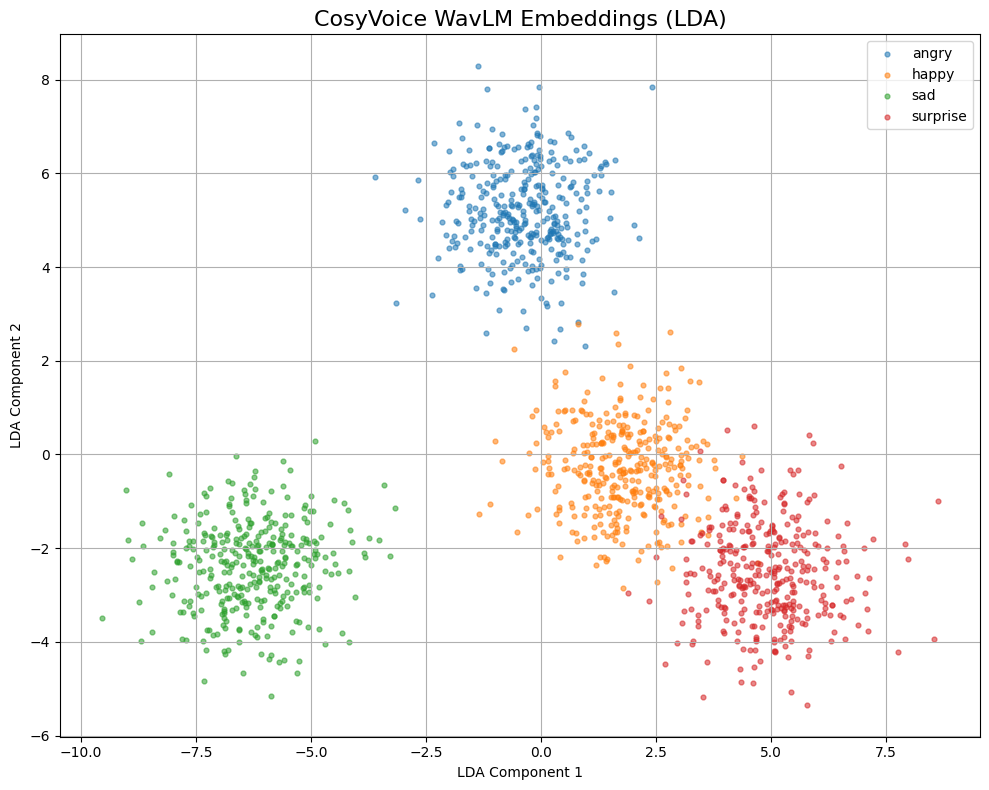

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import LabelEncoder

# =====================
# LOAD EMBEDDINGS
# =====================

X = np.load("cozy_embeddings.npy")
y = np.load("cozy_labels.npy")

print("Embeddings shape:", X.shape)
print("Labels shape:", y.shape)

# =====================
# ENCODE LABELS
# =====================

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# =====================
# LDA
# =====================

lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X, y_encoded)

# =====================
# PLOT
# =====================

plt.figure(figsize=(10,8))

for emotion in encoder.classes_:
    idx = y == emotion
    plt.scatter(
        X_lda[idx, 0],
        X_lda[idx, 1],
        s=12,
        alpha=0.55,
        label=emotion
    )

plt.title("CosyVoice WavLM Embeddings (LDA)", fontsize=16)
plt.xlabel("LDA Component 1")
plt.ylabel("LDA Component 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Subtract Avg from each ParlerTTS audio embedding

import os
import numpy as np

# =========================
# LOAD PARLER CENTROID
# =========================

parler_centroid = np.load("parler_centroid.npy")

# =========================
# PARLER ROOT
# =========================

PARLER_ROOT = (
    "/content/drive/MyDrive/IASNLP Project/data/parlertts/synthetic_audio/0011"
)

parler_centered = []
parler_labels = []

# =========================
# LOAD ALL EMOTIONS
# =========================

for emotion in os.listdir(PARLER_ROOT):

    emotion_path = os.path.join(
        PARLER_ROOT,
        emotion,
        "wavlm_large_mean_embeddings"
    )

    if not os.path.isdir(emotion_path):
        continue

    print("Loading:", emotion)

    for file in os.listdir(emotion_path):

        if file.endswith(".npy"):

            emb = np.load(
                os.path.join(emotion_path, file)
            )

            # Subtract global centroid
            emb = emb - parler_centroid

            parler_centered.append(emb)
            parler_labels.append(emotion)

parler_centered = np.array(parler_centered)
parler_labels = np.array(parler_labels)

print("\nCentered embeddings shape:",
      parler_centered.shape)

print("Labels shape:",
      parler_labels.shape)

# =========================
# SAVE
# =========================

np.save(
    "parler_centered.npy",
    parler_centered
)

np.save(
    "parler_labels.npy",
    parler_labels
)

print("\nSaved centered embeddings and labels.")

Loading: Surprise
Loading: Sad
Loading: Neutral
Loading: Happy
Loading: Angry

Centered embeddings shape: (1750, 1024)
Labels shape: (1750,)

Saved centered embeddings and labels.


Embeddings shape: (1400, 1024)
Labels shape: (1400,)
Explained Variance Ratio:
[0.10345754 0.05272676]


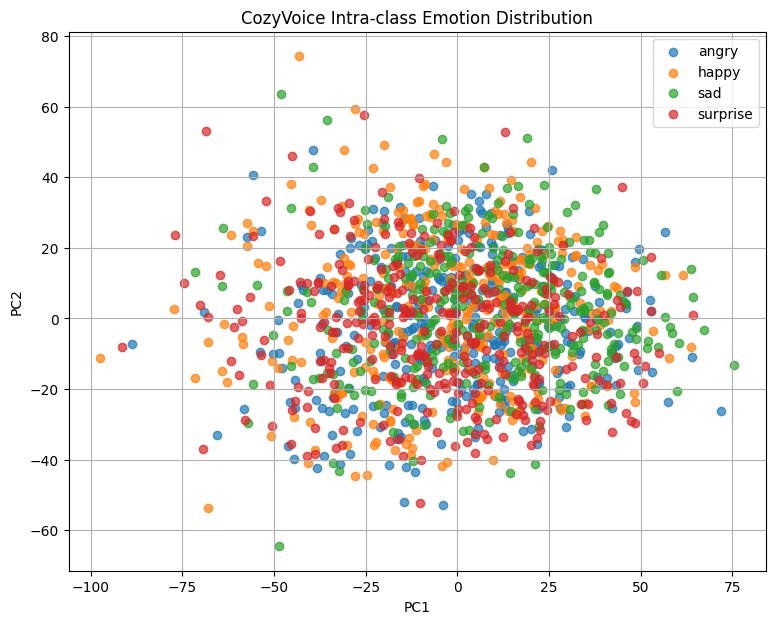

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

# =========================
# LOAD COZY EMBEDDINGS
# =========================

X = np.load("cozy_embeddings.npy")
labels = np.load("cozy_labels.npy")

print("Embeddings shape:", X.shape)
print("Labels shape:", labels.shape)

# =========================
# PCA
# =========================

pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(X)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

# =========================
# PLOT
# =========================

plt.figure(figsize=(9,7))

emotions = np.unique(labels)

for emotion in emotions:

    idx = labels == emotion

    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        alpha=0.7,
        label=emotion
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("CozyVoice Intra-class Emotion Distribution")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Cosine between Avg centroids. Not important. Just a metric

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

natural = np.load("natural_angry_centered.npy")
parler = np.load("parler_angry_centered.npy")

natural_mean = np.mean(natural, axis=0)
parler_mean = np.mean(parler, axis=0)

sim = cosine_similarity(
    natural_mean.reshape(1, -1),
    parler_mean.reshape(1, -1)
)[0,0]

print("Cosine Similarity:", sim)

Cosine Similarity: 0.21433246


In [ ]:
# Just Analysis

import numpy as np

natural = np.load("natural_angry_centered.npy")
parler = np.load("parler_angry_centered.npy")

natural_mean = np.mean(natural, axis=0)
parler_mean = np.mean(parler, axis=0)

print("Natural shift norm:",
      np.linalg.norm(natural_mean))

print("Parler shift norm:",
      np.linalg.norm(parler_mean))

Natural shift norm: 17.114244
Parler shift norm: 3.5131392


In [ ]:
# Not important. Just a metric

from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(
    natural_angry_centered,
    parler_angry_centered
)

print(sim_matrix.shape)
print("Mean similarity:", sim_matrix.mean())
print("Max similarity:", sim_matrix.max())
print("Min similarity:", sim_matrix.min())

(350, 350)
Mean similarity: 0.0017877654
Max similarity: 0.8720073
Min similarity: -0.56096584


Embeddings shape: (1400, 1024)
Labels shape: (1400,)


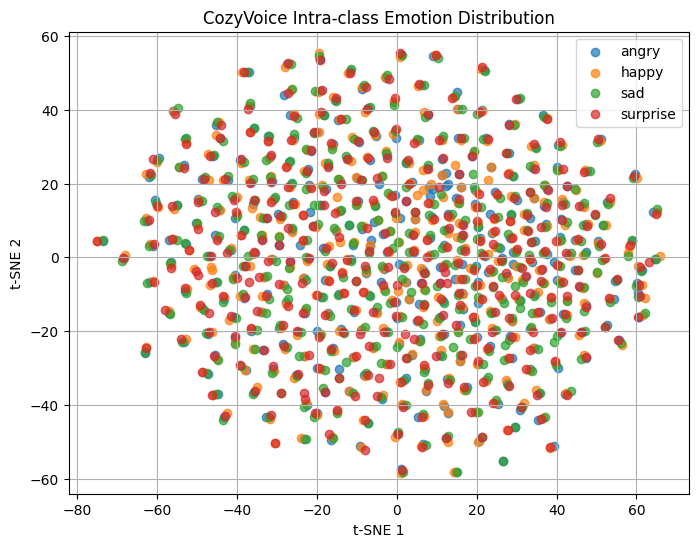

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE

# =========================
# LOAD COZY EMBEDDINGS
# =========================

X = np.load("cozy_embeddings.npy")
labels = np.load("cozy_labels.npy")

print("Embeddings shape:", X.shape)
print("Labels shape:", labels.shape)

# =========================
# t-SNE
# =========================

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(X)

# =========================
# PLOT
# =========================

plt.figure(figsize=(8,6))

emotions = np.unique(labels)

for emotion in emotions:

    idx = labels == emotion

    plt.scatter(
        X_tsne[idx, 0],
        X_tsne[idx, 1],
        alpha=0.7,
        label=emotion
    )

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

plt.title("CozyVoice Intra-class Emotion Distribution")

plt.legend()
plt.grid(True)

plt.show()

Embeddings shape: (1400, 1024)
Labels shape: (1400,)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


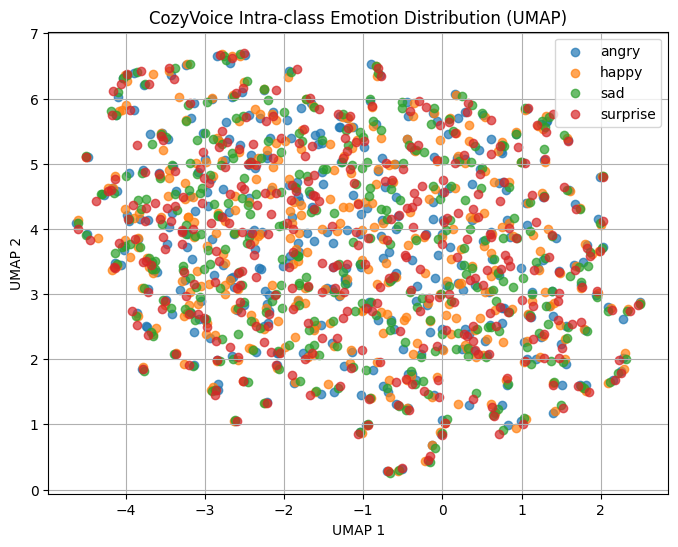

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import umap

# =========================
# LOAD COZY EMBEDDINGS
# =========================

X = np.load("cozy_embeddings.npy")
labels = np.load("cozy_labels.npy")

print("Embeddings shape:", X.shape)
print("Labels shape:", labels.shape)

# =========================
# UMAP
# =========================

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = reducer.fit_transform(X)

# =========================
# PLOT
# =========================

plt.figure(figsize=(8,6))

emotions = np.unique(labels)

for emotion in emotions:

    idx = labels == emotion

    plt.scatter(
        X_umap[idx, 0],
        X_umap[idx, 1],
        alpha=0.7,
        label=emotion
    )

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.title("CozyVoice Intra-class Emotion Distribution (UMAP)")

plt.legend()
plt.grid(True)

plt.show()

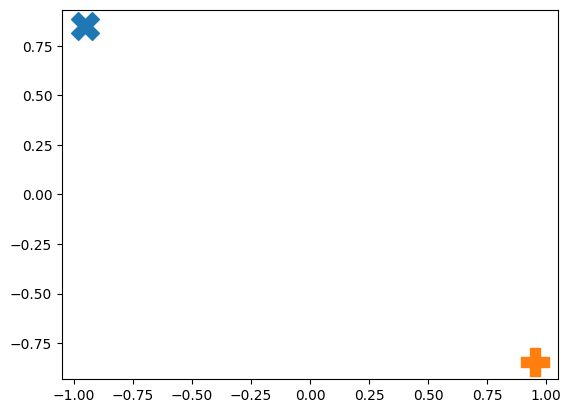

In [ ]:
# Just centroid positions of the Avg of 2 clusters. Not important

natural_center = X_pca[natural_idx].mean(axis=0)
parler_center = X_pca[parler_idx].mean(axis=0)

plt.scatter(
    natural_center[0],
    natural_center[1],
    s=400,
    marker='X',
    label='Natural centroid'
)

plt.scatter(
    parler_center[0],
    parler_center[1],
    s=400,
    marker='P',
    label='Parler centroid'
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# =========================
# 3D PCA
# =========================

natural = np.load("natural_angry_centered.npy")
parler = np.load("parler_angry_centered.npy")

X = np.vstack([natural, parler])

labels = np.array(
    ["Natural"] * len(natural)
    +
    ["ParlerTTS"] * len(parler)
)

pca3 = PCA(n_components=3, random_state=42)
X_pca3 = pca3.fit_transform(X)

print("Explained variance ratio (PC1, PC2, PC3):", pca3.explained_variance_ratio_)
print("Cumulative variance explained by 3 PCs:", pca3.explained_variance_ratio_.sum())
print("(Compare this to the 2-PC number from the earlier cell -- ")
print(" if PC3 adds very little, 2D was already telling the full story.)")

Explained variance ratio (PC1, PC2, PC3): [0.10220804 0.0478995  0.03657134]
Cumulative variance explained by 3 PCs: 0.18667887
(Compare this to the 2-PC number from the earlier cell -- 
 if PC3 adds very little, 2D was already telling the full story.)


In [ ]:
import numpy as np

labels = np.load("parler_labels.npy")

unique, counts = np.unique(labels, return_counts=True)

for u, c in zip(unique, counts):
    print(u, c)

Angry 350
Happy 350
Neutral 350
Sad 350
Surprise 350


In [ ]:
import numpy as np

X = np.load("parler_centered.npy")

print("Shape:", X.shape)

print("Variance:", np.var(X))
print("Mean:", np.mean(X))
print("Min:", np.min(X))
print("Max:", np.max(X))

Shape: (1750, 1024)
Variance: 9.239567
Mean: -2.3609826e-07
Min: -158.8584
Max: 84.39897


In [ ]:
import numpy as np

X = np.load("parler_embeddings.npy")
y = np.load("parler_labels.npy")

for emotion in np.unique(y):
    idx = np.where(y == emotion)[0][0]
    print(emotion)
    print(X[idx][:10])
    print()

Angry
[  4.5968947   -0.8864512   -7.8711224    3.9322336   -1.2427671
 -10.824286    -0.39977977  -2.7027605    0.308908    -0.06928887]

Happy
[  6.1053123  -3.4648242  -7.7998505   0.6633207  -2.186102  -13.121945
   1.7212175  -3.9279158   2.2349257  -1.4317048]

Neutral
[  2.0466666   -2.494299    -5.8454685    0.06157674  -1.0832314
 -11.155786     4.380839     2.0941741   -4.23466     -0.9481124 ]

Sad
[  4.6978145  -5.2235126 -11.062439    0.9611968  -6.1357894 -12.231487
   3.144328   -2.0153992  -3.0443997  -2.0245302]

Surprise
[  4.9828415   -5.585635    -6.1217895    1.198095    -3.172017
 -11.820479    -0.85803425  -4.0075116   -4.6605678   -1.1772162 ]



In [ ]:
# Random Forest - ParlerTTS Intra-class Emotion Classification

import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# =====================
# LOAD EMBEDDINGS
# =====================

X = np.load("parler_embeddings.npy")
y = np.load("parler_labels.npy")

print("Embeddings shape:", X.shape)
print("Labels shape:", y.shape)

# =====================
# TRAIN TEST SPLIT
# =====================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =====================
# RANDOM FOREST
# =====================

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# =====================
# PREDICT
# =====================

y_pred = rf.predict(X_test)

# =====================
# RESULTS
# =====================

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Embeddings shape: (1750, 1024)
Labels shape: (1750,)

Accuracy:
0.06571428571428571

Confusion Matrix:
[[ 4 18 13 16 19]
 [13  6  8 24 19]
 [15 15  6 15 19]
 [18 14 16  6 16]
 [20 20 16 13  1]]

Classification Report:
              precision    recall  f1-score   support

       Angry       0.06      0.06      0.06        70
       Happy       0.08      0.09      0.08        70
     Neutral       0.10      0.09      0.09        70
         Sad       0.08      0.09      0.08        70
    Surprise       0.01      0.01      0.01        70

    accuracy                           0.07       350
   macro avg       0.07      0.07      0.07       350
weighted avg       0.07      0.07      0.07       350



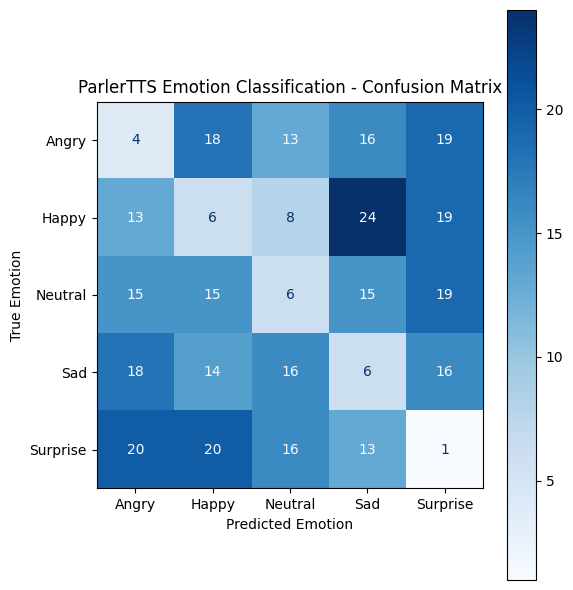

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Automatically get the emotion labels
labels = np.unique(y)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(
    ax=ax,
    cmap="Blues",
    colorbar=True,
    values_format="d"
)

plt.title("ParlerTTS Emotion Classification - Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.tight_layout()
plt.show()